<a href="https://colab.research.google.com/github/SamuelMbogo/Colab_projects/blob/main/Introduction_to_Quantitative_Finance_v3_(Helping_Rhea).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

class FinancialAnalysis:
    def __init__(self, start_date="2004-11-01", end_date="2024-12-31"):
        """Initialize with date range for analysis"""
        self.start_date = start_date
        self.end_date = end_date
        self.tickers = ['^SPX', '^IXIC', '^VIX', '^IRX']
        self.data = None
        self.month_end_data = None
        self.historical_events = {
            '2008-09-15': 'Lehman Brothers Bankruptcy',
            '2020-03-15': 'COVID-19 Market Crash',
            '2022-02-24': 'Russia-Ukraine Conflict'
        }

    def fetch_data(self):
        """Download and prepare financial data"""
        print("Fetching data from Yahoo Finance...")
        self.data = yf.download(self.tickers, start=self.start_date, end=self.end_date)
        self.month_end_data = self.data.resample('M').last()
        return self.month_end_data

    def calculate_returns(self, ticker='^SPX'):
        """Calculate various return metrics for given ticker"""
        data = self.month_end_data.xs(ticker, level=1, axis=1)
        monthly_returns = data['Close'].pct_change().dropna()

        # Print first 5 and last 5 records
        print("\nFirst 5 monthly returns:")
        print(monthly_returns.head().apply(lambda x: f"{x:.2%}"))
        print("\nLast 5 monthly returns:")
        print(monthly_returns.tail().apply(lambda x: f"{x:.2%}"))

        # Calculate 20-year compounded return
        comp_return = (1 + monthly_returns).prod() - 1
        print(f"\n20-Year Compounded Return: {comp_return:.2%}")

        # Calculate annualized return
        years = (monthly_returns.index[-1] - monthly_returns.index[0]).days / 365.25
        annual_return = np.log(1 + comp_return) / years
        print(f"Annualized Return: {annual_return:.2%}")

        return {
            'monthly_returns': monthly_returns,
            'compounded_return': comp_return,
            'annualized_return': annual_return
        }

    def analyze_vix_irx_relationship(self):
        """Analyze relationship between VIX spikes and interest rates with historical examples"""
        vix_data = self.month_end_data.xs('^VIX', level=1, axis=1)['Close']
        irx_data = self.month_end_data.xs('^IRX', level=1, axis=1)['Close']

        # Define VIX spike threshold (2 standard deviations)
        vix_mean = vix_data.mean()
        vix_std = vix_data.std()
        spike_threshold = vix_mean + 2 * vix_std

        # Identify VIX spike periods
        spike_periods = vix_data[vix_data > spike_threshold]

        # Analyze historical events
        historical_analysis = []
        for date, event in self.historical_events.items():
            event_date = pd.to_datetime(date)
            window = slice(event_date - pd.Timedelta(days=30), event_date + pd.Timedelta(days=30))

            if event_date in vix_data.index:
                vix_change = vix_data.loc[event_date] / vix_data.loc[event_date - pd.Timedelta(days=30)] - 1
                irx_change = irx_data.loc[event_date] / irx_data.loc[event_date - pd.Timedelta(days=30)] - 1

                historical_analysis.append({
                    'Event': event,
                    'Date': event_date,
                    'VIX_Change': vix_change,
                    'IRX_Change': irx_change
                })

        return pd.DataFrame(historical_analysis)

    def implement_ml_models(self):
        """Implement both regime detection and market trend prediction models"""
        # Prepare features
        data = pd.DataFrame({
            'VIX': self.month_end_data.xs('^VIX', level=1, axis=1)['Close'],
            'SPX_Returns': self.month_end_data.xs('^SPX', level=1, axis=1)['Close'].pct_change(),
            'IRX': self.month_end_data.xs('^IRX', level=1, axis=1)['Close'],
            'IXIC_Returns': self.month_end_data.xs('^IXIC', level=1, axis=1)['Close'].pct_change()
        }).dropna()

        # Add technical indicators
        data['VIX_MA20'] = data['VIX'].rolling(window=20).mean()
        data['SPX_MA50'] = data['SPX_Returns'].rolling(window=50).mean()
        data['VIX_STD20'] = data['VIX'].rolling(window=20).std()

        # 1. Regime Detection Model
        data['Regime'] = (data['VIX'] > data['VIX'].mean() + data['VIX'].std()).astype(int)

        X_regime = data[['VIX', 'SPX_Returns', 'IRX', 'VIX_MA20', 'VIX_STD20']]
        y_regime = data['Regime']

        # 2. Market Trend Prediction Model
        # Create forward returns for prediction
        data['Forward_Return'] = data['SPX_Returns'].shift(-1)

        X_trend = data[['VIX', 'SPX_Returns', 'IRX', 'IXIC_Returns', 'VIX_MA20', 'SPX_MA50']]
        y_trend = data['Forward_Return'].shift(-1)

        # Remove NaN values
        X_trend = X_trend[:-1]
        y_trend = y_trend[:-1].fillna(0)

        # Split data for both models
        X_regime_train, X_regime_test, y_regime_train, y_regime_test = train_test_split(
            X_regime, y_regime, test_size=0.2, random_state=42
        )
        X_trend_train, X_trend_test, y_trend_train, y_trend_test = train_test_split(
            X_trend, y_trend, test_size=0.2, random_state=42
        )

        # Scale features
        scaler = StandardScaler()
        X_regime_train_scaled = scaler.fit_transform(X_regime_train)
        X_regime_test_scaled = scaler.transform(X_regime_test)

        scaler_trend = StandardScaler()
        X_trend_train_scaled = scaler_trend.fit_transform(X_trend_train)
        X_trend_test_scaled = scaler_trend.transform(X_trend_test)

        # Train and evaluate regime detection model
        regime_model = RandomForestClassifier(n_estimators=100, random_state=42)
        regime_model.fit(X_regime_train_scaled, y_regime_train)
        regime_pred = regime_model.predict(X_regime_test_scaled)

        # Train and evaluate trend prediction model
        trend_model = RandomForestRegressor(n_estimators=100, random_state=42)
        trend_model.fit(X_trend_train_scaled, y_trend_train)
        trend_pred = trend_model.predict(X_trend_test_scaled)

        return {
            'regime_classification_report': classification_report(y_regime_test, regime_pred),
            'trend_prediction_rmse': np.sqrt(mean_squared_error(y_trend_test, trend_pred)),
            'trend_prediction_r2': r2_score(y_trend_test, trend_pred)
        }

def main():
    """Main execution function"""
    # Initialize and run financial analysis
    fa = FinancialAnalysis()
    fa.fetch_data()

    # Complete return analysis
    print("\nS&P 500 Return Analysis:")
    spx_returns = fa.calculate_returns('^SPX')

    # Analyze VIX-IRX relationship with historical examples
    historical_analysis = fa.analyze_vix_irx_relationship()
    print("\nHistorical Market Stress Events Analysis:")
    print(historical_analysis)

    # Run machine learning analysis
    ml_results = fa.implement_ml_models()
    print("\nMachine Learning Results:")
    print("\nRegime Detection Model Performance:")
    print(ml_results['regime_classification_report'])
    print("\nMarket Trend Prediction Performance:")
    print(f"RMSE: {ml_results['trend_prediction_rmse']:.4f}")
    print(f"R² Score: {ml_results['trend_prediction_r2']:.4f}")

if __name__ == "__main__":
    main()

[                       0%                       ]

Fetching data from Yahoo Finance...


[*********************100%***********************]  4 of 4 completed



S&P 500 Return Analysis:

First 5 monthly returns:
Date
2004-12-31     3.25%
2005-01-31    -2.53%
2005-02-28     1.89%
2005-03-31    -1.91%
2005-04-30    -2.01%
Freq: ME, Name: Close, dtype: object

Last 5 monthly returns:
Date
2024-08-31     2.28%
2024-09-30     2.02%
2024-10-31    -0.99%
2024-11-30     5.73%
2024-12-31    -2.08%
Freq: ME, Name: Close, dtype: object

20-Year Compounded Return: 403.22%
Annualized Return: 8.08%

Historical Market Stress Events Analysis:
Empty DataFrame
Columns: []
Index: []

Machine Learning Results:

Regime Detection Model Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00         8

    accuracy                           1.00        49
   macro avg       1.00      1.00      1.00        49
weighted avg       1.00      1.00      1.00        49


Market Trend Prediction Performance:
RMSE: 0.0443
R² Score: -0.3761


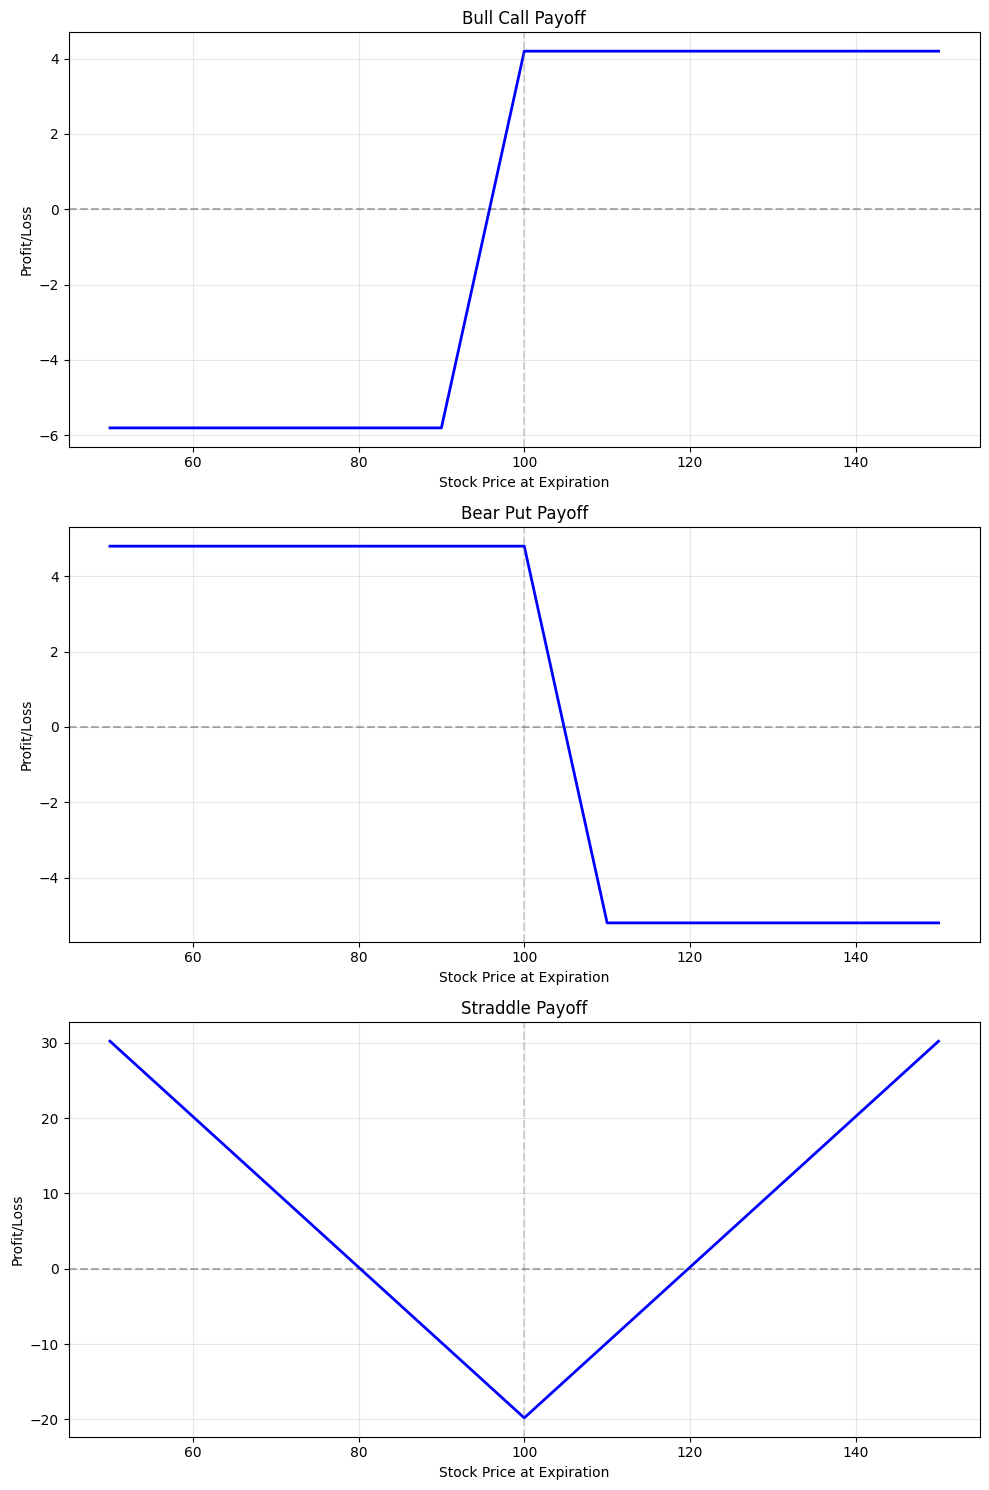


Strategy Analysis:

Bull Call:
Max Profit: 4.195235979762479
Max Loss: 5.804764020237521
Breakeven: 95.80476402023753

Bear Put:
Max Profit: 5.2026800084917895
Max Loss: 4.7973199915082105
Breakeven: 104.7973199915082

Straddle:
Max Profit: Unlimited
Max Loss: 19.79494031080884
Lower Breakeven: 80.20505968919116
Upper Breakeven: 119.79494031080884

Dividend Impact Analysis:
call_K1: -12.28% change due to dividends
call_K2: -14.48% change due to dividends
put_K2: 15.67% change due to dividends
put_K3: 12.75% change due to dividends


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

class OptionsAnalysis:
    def __init__(self, S=100, K1=90, K2=100, K3=110, T=1, r=0.05, sigma=0.25, q=0.03):
        self.S = S          # Current stock price
        self.K1 = K1        # Strike price 1
        self.K2 = K2        # Strike price 2
        self.K3 = K3        # Strike price 3
        self.T = T          # Time to maturity
        self.r = r          # Risk-free rate
        self.sigma = sigma  # Volatility
        self.q = q          # Dividend yield
        self.S_range = np.arange(50, 155, 5)  # Stock price range for analysis

    def black_scholes(self, K, option_type='call', with_dividend=False):
        """Calculate Black-Scholes option price"""
        S_adj = self.S * np.exp(-self.q * self.T) if with_dividend else self.S
        d1 = (np.log(S_adj/K) + (self.r + self.sigma**2/2)*self.T) / (self.sigma*np.sqrt(self.T))
        d2 = d1 - self.sigma*np.sqrt(self.T)

        if option_type == 'call':
            price = S_adj*norm.cdf(d1) - K*np.exp(-self.r*self.T)*norm.cdf(d2)
        else:  # put
            price = K*np.exp(-self.r*self.T)*norm.cdf(-d2) - S_adj*norm.cdf(-d1)

        return price

    def calculate_strategy_payoffs(self):
        """Calculate payoffs for all strategies"""
        # Calculate option prices
        call_K1 = self.black_scholes(self.K1, 'call')
        call_K2 = self.black_scholes(self.K2, 'call')
        put_K2 = self.black_scholes(self.K2, 'put')
        put_K3 = self.black_scholes(self.K3, 'put')

        payoffs = {}

        # Bull Call Spread payoff
        payoffs['bull_call'] = {
            'payoff': np.maximum(self.S_range - self.K1, 0) - np.maximum(self.S_range - self.K2, 0) - (call_K1 - call_K2),
            'max_profit': self.K2 - self.K1 - (call_K1 - call_K2),
            'max_loss': call_K1 - call_K2,
            'breakeven': self.K1 + call_K1 - call_K2
        }

        # Bear Put Spread payoff
        payoffs['bear_put'] = {
            'payoff': np.maximum(self.K3 - self.S_range, 0) - np.maximum(self.K2 - self.S_range, 0) - (put_K3 - put_K2),
            'max_profit': put_K3 - put_K2,
            'max_loss': self.K3 - self.K2 - (put_K3 - put_K2),
            'breakeven': self.K3 - (put_K3 - put_K2)
        }

        # Straddle payoff
        payoffs['straddle'] = {
            'payoff': np.maximum(self.S_range - self.K2, 0) + np.maximum(self.K2 - self.S_range, 0) - (call_K2 + put_K2),
            'max_profit': 'Unlimited',
            'max_loss': call_K2 + put_K2,
            'breakeven_low': self.K2 - (call_K2 + put_K2),
            'breakeven_high': self.K2 + (call_K2 + put_K2)
        }

        return payoffs

    def analyze_dividend_impact(self):
        """Analyze impact of dividends on strategies"""
        regular_prices = {
            'call_K1': self.black_scholes(self.K1, 'call', False),
            'call_K2': self.black_scholes(self.K2, 'call', False),
            'put_K2': self.black_scholes(self.K2, 'put', False),
            'put_K3': self.black_scholes(self.K3, 'put', False)
        }

        dividend_prices = {
            'call_K1': self.black_scholes(self.K1, 'call', True),
            'call_K2': self.black_scholes(self.K2, 'call', True),
            'put_K2': self.black_scholes(self.K2, 'put', True),
            'put_K3': self.black_scholes(self.K3, 'put', True)
        }

        return {
            'regular': regular_prices,
            'with_dividend': dividend_prices,
            'impact_percentage': {k: (dividend_prices[k] - regular_prices[k])/regular_prices[k]
                                for k in regular_prices.keys()}
        }

    def plot_strategy_payoffs(self, payoffs):
        """Plot payoff diagrams for all strategies"""
        strategies = list(payoffs.keys())
        fig, axes = plt.subplots(len(strategies), 1, figsize=(10, 15))

        for ax, strategy in zip(axes, strategies):
            ax.plot(self.S_range, payoffs[strategy]['payoff'], 'b-', linewidth=2)
            ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
            ax.axvline(x=self.K2, color='gray', linestyle='--', alpha=0.3)
            ax.set_title(f"{strategy.replace('_', ' ').title()} Payoff")
            ax.set_xlabel("Stock Price at Expiration")
            ax.set_ylabel("Profit/Loss")
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        return fig

def main():
    # Initialize analysis
    oa = OptionsAnalysis()

    # Calculate payoffs
    payoffs = oa.calculate_strategy_payoffs()

    # Plot payoffs
    oa.plot_strategy_payoffs(payoffs)
    plt.show()

    # Print strategy analysis
    print("\nStrategy Analysis:")
    for strategy, data in payoffs.items():
        print(f"\n{strategy.replace('_', ' ').title()}:")
        print(f"Max Profit: {data['max_profit']}")
        print(f"Max Loss: {data['max_loss']}")
        if strategy != 'straddle':
            print(f"Breakeven: {data['breakeven']}")
        else:
            print(f"Lower Breakeven: {data['breakeven_low']}")
            print(f"Upper Breakeven: {data['breakeven_high']}")

    # Analyze dividend impact
    dividend_analysis = oa.analyze_dividend_impact()
    print("\nDividend Impact Analysis:")
    for option, impact in dividend_analysis['impact_percentage'].items():
        print(f"{option}: {impact:.2%} change due to dividends")

if __name__ == "__main__":
    main()